In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

In [3]:
from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery

In [4]:
# Once you have the dataset, either generated or downloaded
# Notice that the dataset has `time_series` and `adjacency_matrix` variables.
DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")

# Extract timeseries and adjacency matrix as target
timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
adj_matrix = ds['adjacency_matrix'].to_numpy()

# NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
## timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
## adj_matrix = ds['adjacency_matrix_summary'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system


In [5]:
timeseries.shape

(10, 1000, 3)

In [6]:
adj_matrix.shape

(3, 3)

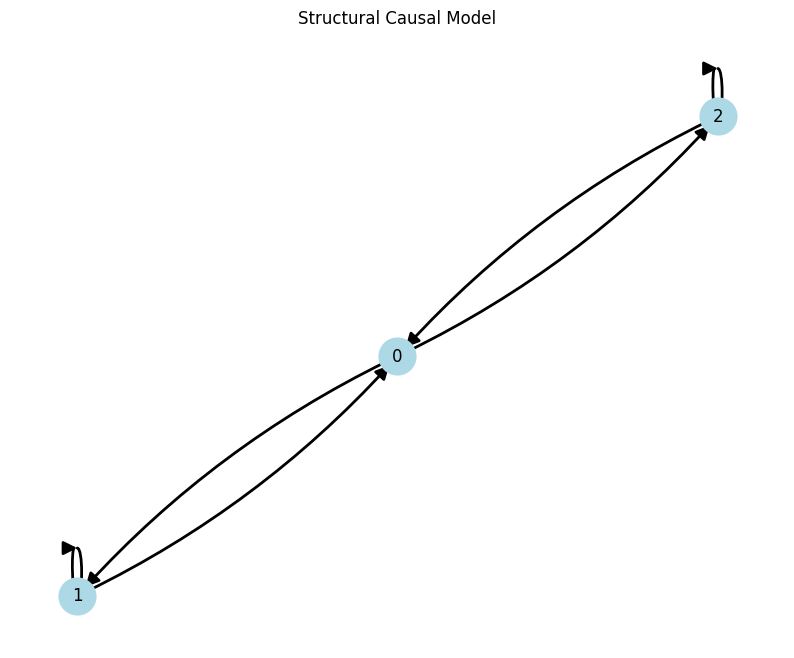

In [7]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [8]:
tau = 0
T = timeseries.shape[1]
D = timeseries.shape[-1]
timeseries_stacked = np.stack([np.stack([timeseries[k, i:i + tau + 1] for i in range(T - tau)]) for k in range(timeseries.shape[0])])
timeseries_stacked.shape

(10, 1000, 1, 3)

In [31]:
timeseries[0, :, 2].ptp()

21.933735

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
timeseries_stacked.shape

(10, 1000, 1, 3)

In [41]:
tau_max = 1 # i.e. one delay only
# no instantaneous? 

## Estimate adjacency matrix
lowrank_adj_matrix = []
lowrank_S_matrix = []

for x in [timeseries_stacked[0]]:
    lowrank_model = StructuredLowRankDiscovery(
        k = 1,
        n = 3,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 64, n_layers = 4,
        t = tau_max,
        device = device,
    )
    trained_mode, mask = lowrank_model.run(X=torch.tensor(x).to(device), th=0.1, lr=0.0001, lambda_s = 0.001, lambda_w = 0.001, n_outer = 10, n_inner_min_sparse = 0, batch_size=32, n_inner=1000)
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))



Dimensions: N=3, K=1, T=1
X.shape = torch.Size([1000, 1, 3])
X.mean(dim=0) = tensor([[ 4.7088e-09,  2.7418e-09, -1.5140e-08]], device='cuda:0')
X.std(dim=0) = tensor([[1., 1., 1.]], device='cuda:0')
X_t_all.shape = torch.Size([999, 1, 3])
X_last_all.shape = torch.Size([999, 1, 3])
outer=01  h(W)=0.00000  recon=0.0008  entropy=0.000  |W|_1=0.000  |M|_1=7.230  lambda=0.000  mu=0.00
  → Sparsification converged: no coefficients below threshold=0.1


In [43]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [42]:
(torch.sigmoid(lowrank_model.model.M_logits) * 1000).detach().cpu().numpy().astype('int') // 10 / 100

array([[[0.93, 0.64, 0.93],
        [0.63, 0.93, 0.93],
        [0.7 , 0.54, 0.94]],

       [[0.95, 0.95, 0.95],
        [0.95, 0.95, 0.95],
        [0.95, 0.95, 0.95]]])

1333.3333333333333

In [13]:
full_causalres = 1*(np.array(lowrank_adj_matrix)[:, 0] >= 0.5) #[0]

In [15]:
## Compute scores
score(
    preds= np.array(lowrank_adj_matrix)[:, 0],
    labs= adj_matrix,
    name='LR_discovery'
)



Scoring...


,LR_discovery
Metric,
Joint AUROC,0.750000
Individual AUROC,0.750000
Null AUROC,0.500000
Joint AUPRC,0.805556
Individual AUPRC,0.805556
Null AUPRC,0.666667
Joint SHD,2.000000


In [89]:
8.000000/3

2.6666666666666665